# Test a new Docker image

Takes an existing Vertex AI model, registers a `_test` clone that points at the **same artifacts** but uses a **new serving container image**, deploys it to a fresh endpoint, sends a sample prediction, and cleans up. Useful for verifying a new docker image before promoting it to the production model registration.

Set `ORIGINAL_MODEL_NAME` and `NEW_IMAGE_URI` in the config cell, then run top-to-bottom.

## Configuration

In [10]:
from google.cloud import aiplatform

PROJECT = "shiftsmart-api"
REGION = "us-west1"

ORIGINAL_MODEL_NAME = "pepsi-bev-detection"  # display_name of the existing model in Vertex
NEW_IMAGE_URI = "us-west1-docker.pkg.dev/shiftsmart-api/orient-express/image-onnx:v2.4.1"

TEST_MODEL_NAME = f"{ORIGINAL_MODEL_NAME}"

aiplatform.init(project=PROJECT, location=REGION)

## Find the original model

We reuse its `artifact_uri` so the new test model points at the same GCS path of model artifacts.

In [11]:
existing = aiplatform.Model.list(filter=f'display_name="{ORIGINAL_MODEL_NAME}"')
assert existing, f"No model found with display_name={ORIGINAL_MODEL_NAME!r}"

original = sorted(existing, key=lambda m: m.update_time, reverse=True)[0]
artifact_uri = original.gca_resource.artifact_uri

print(f"Original model:  {original.resource_name}")
print(f"Artifact URI:    {artifact_uri}")

Original model:  projects/335608921120/locations/us-west1/models/1008045454484570112
Artifact URI:    gs://shiftsmart-ml/models/pepsi-bev-detection/1/


## Register the `_test` model

Same artifacts, new container image. Routes match orient-express's kserve convention (`/v1/models/<MODEL_NAME>...`), and `MODEL_NAME` is passed through as an env var so the container binds itself at the matching path.

In [12]:
test_model = aiplatform.Model.upload(
    display_name=TEST_MODEL_NAME,
    artifact_uri=artifact_uri,
    serving_container_image_uri=NEW_IMAGE_URI,
    serving_container_health_route=f"/v1/models/{TEST_MODEL_NAME}",
    serving_container_predict_route=f"/v1/models/{TEST_MODEL_NAME}:predict",
    serving_container_environment_variables={"MODEL_NAME": TEST_MODEL_NAME},
    sync=True,
)
print(f"Test model: {test_model.resource_name}")

Creating Model
Create Model backing LRO: projects/335608921120/locations/us-west1/models/5824961915306115072/operations/3152460502970400768
Model created. Resource name: projects/335608921120/locations/us-west1/models/5824961915306115072@1
To use this Model in another session:
model = aiplatform.Model('projects/335608921120/locations/us-west1/models/5824961915306115072@1')
Test model: projects/335608921120/locations/us-west1/models/5824961915306115072


## Create endpoint and deploy

Deployment takes a few minutes. The cell blocks until the model is ready to serve.

In [13]:
test_endpoint = aiplatform.Endpoint.create(
    display_name=TEST_MODEL_NAME,
    project=PROJECT,
    location=REGION,
)
print(f"Endpoint: {test_endpoint.resource_name}")

Creating Endpoint
Create Endpoint backing LRO: projects/335608921120/locations/us-west1/endpoints/1960387450882752512/operations/6725503857335468032
Endpoint created. Resource name: projects/335608921120/locations/us-west1/endpoints/1960387450882752512
To use this Endpoint in another session:
endpoint = aiplatform.Endpoint('projects/335608921120/locations/us-west1/endpoints/1960387450882752512')
Endpoint: projects/335608921120/locations/us-west1/endpoints/1960387450882752512


In [14]:
test_endpoint.deploy(
    model=test_model,
    machine_type="e2-standard-8",
    min_replica_count=1,
    max_replica_count=1,
    traffic_percentage=100,
)
print(f"Deployed to: {test_endpoint.resource_name}")

Deploying Model projects/335608921120/locations/us-west1/models/5824961915306115072 to Endpoint : projects/335608921120/locations/us-west1/endpoints/1960387450882752512
Deploy Endpoint model backing LRO: projects/335608921120/locations/us-west1/endpoints/1960387450882752512/operations/2786261558269837312
Endpoint model deployed. Resource name: projects/335608921120/locations/us-west1/endpoints/1960387450882752512
Deployed to: projects/335608921120/locations/us-west1/endpoints/1960387450882752512


## Send a test prediction

In [15]:
TEST_IMAGE_URL = "https://storage.googleapis.com/ssm-media-uploads/8c8ebb1b-c7a3-4ba9-bd47-8c0eb741f035/taskImages/26983819-c423-4f57-90dc-f62c018d1eb6/a961dc13-2056-42e6-84f3-8c2bfad66ac3-13-pre-camera-2026-02-09T22%3A57%3A48.000Z"  # http(s), gs://, or base64 data URI

response = test_endpoint.predict(
    instances=[{"image": TEST_IMAGE_URL}],
    parameters={"confidence": 0.5},
)
prediction = response.predictions[0]
print(f"Status: {prediction.get('status')}")
print(f"Fields: {list(prediction.keys())}")

Status: success
Fields: ['predictions', 'status', 'debug_image']


### Debug image

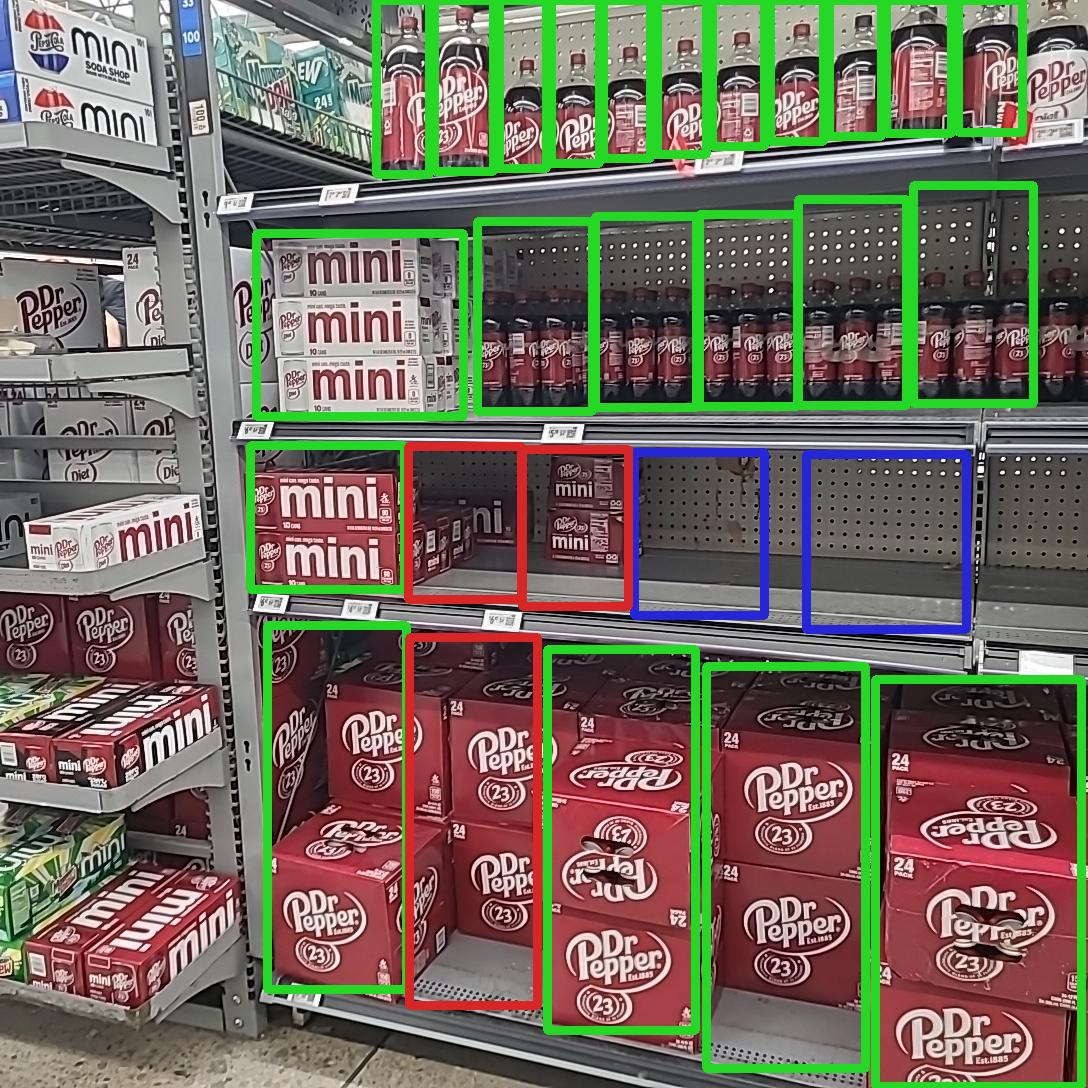

In [17]:
import base64
from IPython.display import Image, display

debug_b64 = prediction.get("debug_image")
if debug_b64:
    display(Image(data=base64.b64decode(debug_b64)))
else:
    print("No debug image in response")

### Segmentation masks (if returned)

Only populated for semantic-segmentation predictors.

In [ ]:
inner = prediction.get("predictions") or {}
class_mask_b64 = inner.get("class_mask") if isinstance(inner, dict) else None
valid_mask_b64 = inner.get("valid_mask") if isinstance(inner, dict) else None

if class_mask_b64:
    print("class_mask:")
    display(Image(data=base64.b64decode(class_mask_b64)))
if valid_mask_b64:
    print("valid_mask:")
    display(Image(data=base64.b64decode(valid_mask_b64)))
if not class_mask_b64 and not valid_mask_b64:
    print("No segmentation masks in response")

## Cleanup

Undeploys the model, deletes the endpoint, and deletes the `_test` model registration. The original model and its artifacts are untouched.

In [8]:
test_endpoint.undeploy_all()
test_endpoint.delete()
test_model.delete()
print("Cleaned up")

Undeploying Endpoint model: projects/335608921120/locations/us-west1/endpoints/7702476975780134912
Undeploy Endpoint model backing LRO: projects/335608921120/locations/us-west1/endpoints/7702476975780134912/operations/8013075953926275072
Endpoint model undeployed. Resource name: projects/335608921120/locations/us-west1/endpoints/7702476975780134912
Deleting Endpoint : projects/335608921120/locations/us-west1/endpoints/7702476975780134912
Endpoint deleted. . Resource name: projects/335608921120/locations/us-west1/endpoints/7702476975780134912
Deleting Endpoint resource: projects/335608921120/locations/us-west1/endpoints/7702476975780134912
Delete Endpoint backing LRO: projects/335608921120/locations/us-west1/operations/318675990563782656
Endpoint resource projects/335608921120/locations/us-west1/endpoints/7702476975780134912 deleted.
Deleting Model : projects/335608921120/locations/us-west1/models/519721554263670784
Model deleted. . Resource name: projects/335608921120/locations/us-west